# Taller 2: operaciones de transformación del histograma

### Sebastián Palma

### David Tobón Molina

In [450]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

from skimage import exposure

In [451]:
def get_histogram(img):
    return cv2.calcHist([img],[0],None,[256],[0,256])

# 1. Calibración del histograma

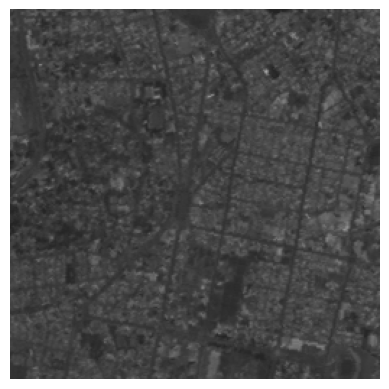

In [452]:
quito_img = cv2.imread('images/QUITO.png', cv2.IMREAD_GRAYSCALE)

plt.imshow(quito_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 1.3. Visualice el histograma de la imagen. Describa su forma. ¿Cuáles son los niveles de gris mínimo y máximo?. 

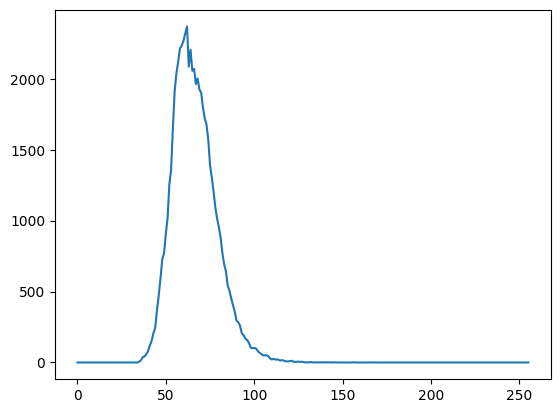

In [453]:
quito_hist = get_histogram(quito_img)
plt.plot(quito_hist)
plt.show()

In [454]:
print(np.min(quito_img), np.max(quito_img))

35 166


El histograma tiene su mayor densidad en un gran pico alrededor de los niveles de intensidad entre 40 y 100, donde el pico obtiene su máximo valor (mayor números de píxeles) para el nivel de intensidad de grises de 60. Las demás áreas del histograma son planas.

Al observar el histograma parece que el nivel de gris mínimo es 40 y el máximo es de 130. Aunque, usando las funciones de numpy, se obtiene que el valor de intensidad mínimo es 35 y el máximo es 166, pero al tener pocos píxeles con dado nivel de intensidad, esto no es observable en el histograma con su zoom actual. 

### 1.4. Efectúe una expansión del contraste, visualice la imagen resultado y el histograma correspondiente. ¿En qué consiste la mejora de la imagen?

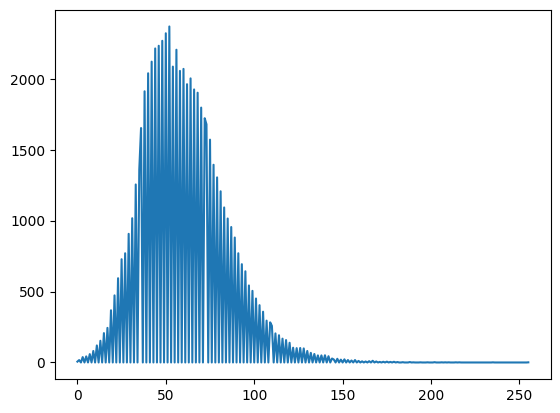

In [455]:
A, B = 35, 166
C, D = 0, 255
rescaled_img = exposure.rescale_intensity(quito_img, in_range=(A,B), out_range=(C,D)).astype(np.uint8)

rescaled_hist = get_histogram(rescaled_img)
plt.plot(rescaled_hist)
plt.show()

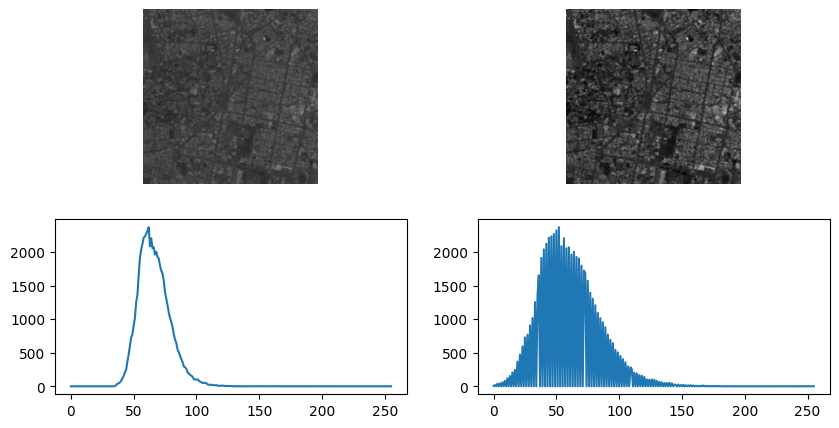

In [456]:
plt.figure(figsize=(10,5))

plt.subplot(2,2,1)
plt.imshow(quito_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(rescaled_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(2,2,3)
plt.plot(quito_hist)

plt.subplot(2,2,4)
plt.plot(rescaled_hist)

plt.show()

La mejora de la imagen consiste en expandir el rango dinámico de la imagen, es decir, aumentar el contraste. Esto se logra al mapear los valores de intensidad de la imagen original (que van de 35 a 166) a un nuevo rango (de 0 a 255). Como resultado, los detalles que antes eran difíciles de distinguir debido a la falta de contraste ahora son más visibles, lo que mejora la calidad visual de la imagen. 

### 1.5. También es posible efectuar una expansión del contraste entre dos valores particulares. Se trata de una transformación lineal del histograma, que permite especificar 2 niveles de gris que deben ser respectivamente llevados a 0 y 255. Esta transformación se llama calibración del histograma.

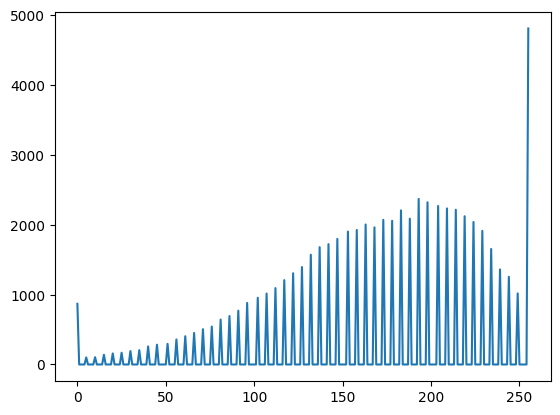

In [457]:
A, B = 50, 100
D, C = 0, 255
rescaled_img = exposure.rescale_intensity(quito_img, in_range=(A,B), out_range=(C,D)).astype(np.uint8)

rescaled_hist = get_histogram(rescaled_img)
plt.plot(rescaled_hist)
plt.show()

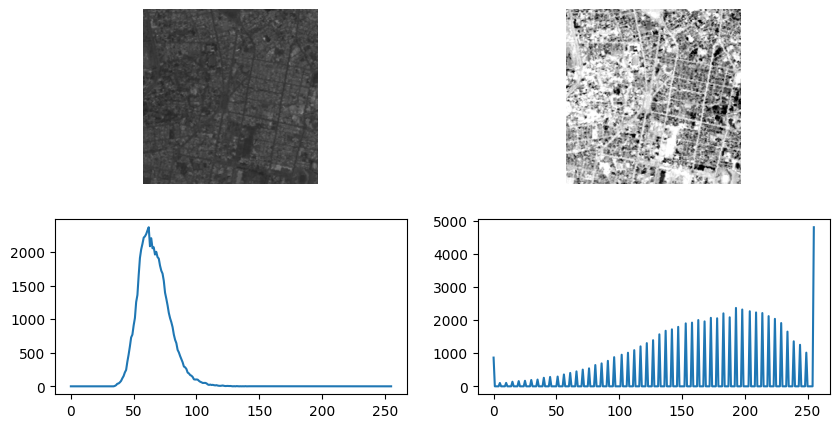

In [458]:
plt.figure(figsize=(10,5))

plt.subplot(2,2,1)
plt.imshow(quito_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(rescaled_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(2,2,3)
plt.plot(quito_hist)

plt.subplot(2,2,4)
plt.plot(rescaled_hist)

plt.show()

Esta transformación busca expandir el nivel de detalle que se encuentra en los tonos de grises entre 50 y 100 (A y B), lo que hace que los detalles que se encuentran en ese rango de intensidad sean más visibles. Sin embargo, al expandir el contraste entre esos niveles de gris, se pierde información en los niveles de intensidad por debajo de 50 y por encima de 100, lo que puede resultar en una pérdida de detalles en esas áreas y la saturación de los tonos extremos. Por lo tanto, aunque se mejora la visibilidad de los detalles entre 50 y 100, se sacrifica la información en los extremos del rango de intensidad.

### 1.6. Efectúe 3 calibraciones diferentes del histograma sobre la imagen original, entre los valores 50-100, 40-120 y 35-166. Visualice los resultados.

In [459]:
a_b_list = [(50, 100), (40,120), (35,166)]
C, D = 0, 255

hist_list = []
rescaled_ims = []
for ab in a_b_list:
    a, b = ab
    rescaled_img = exposure.rescale_intensity(quito_img, in_range=(a,b), out_range=(C,D)).astype(np.uint8)
    rescaled_ims.append(rescaled_img)
    hist_list.append(get_histogram(rescaled_img))
    

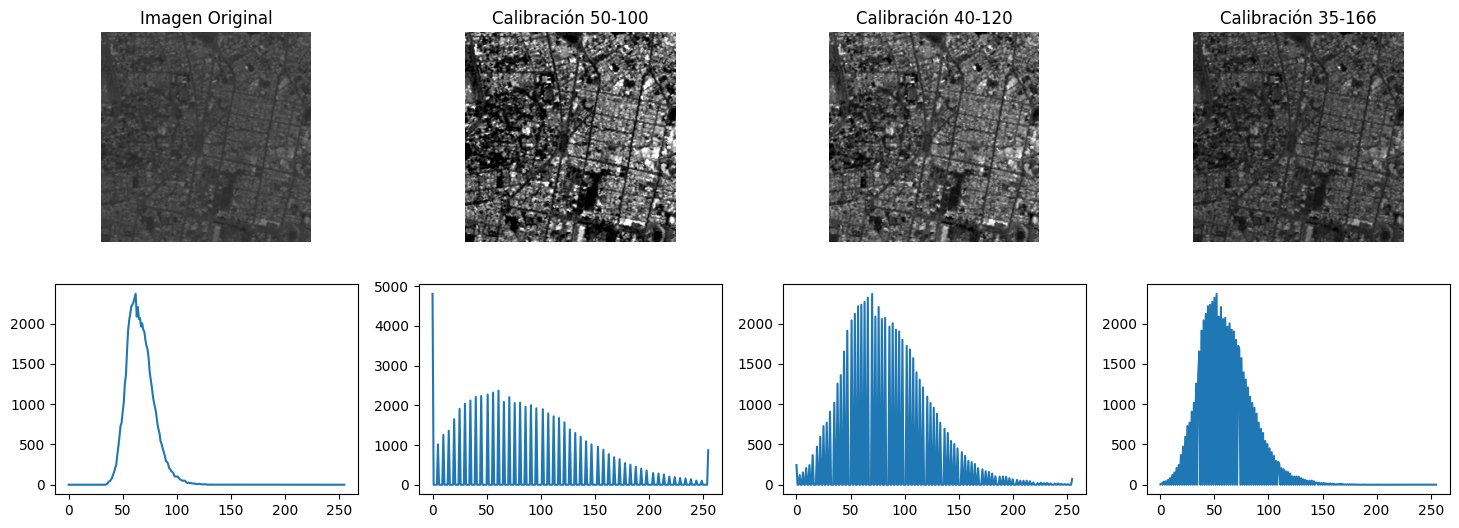

In [460]:
plt.figure(figsize=(18, 6))

plt.subplot(2, 4, 1)
plt.imshow(quito_img, cmap='gray', vmin=0, vmax=255)
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.plot(quito_hist)


for i, (a, b) in enumerate(a_b_list):
    plt.subplot(2, 4, i+2)
    plt.imshow(rescaled_ims[i], cmap='gray', vmin=0, vmax=255)
    plt.title(f'Calibración {a}-{b}')
    plt.axis('off')
    
    plt.subplot(2, 4, i+6)
    plt.plot(hist_list[i])

### 1.7. ¿Cuál es la diferencia entre estas imágenes? ¿Cuál presenta el mejor contraste? ¿Cuál permite ver mejor los detalles? ¿Por qué la calibración entre 35 y 166 da el mismo resultado que la expansión del contraste efectuada en el punto 4? ¿Conclusión?

La diferencia entre las imágenes radica en el rango de niveles de gris que se han expandido. Para un determinado rango, mayor es el contraste en las áreas específicas donde predominaban esas intensidades. Adicionalmente, al tomar un rango de calibración menor, la transformación es más agresiva, provocando que una mayor parte de la imagen se sature, lo que puede resultar en una pérdida de detalles en las áreas fuera del rango seleccionado. Por ejemplo en la calibración de tonos de grises entre 50 y 100, todos los píxeles con niveles de intensidad por debajo de 50 se vuelven completamente negros (0), y los píxeles por encima de 100 se vuelven blancos (255). La calibración 40-120 es un punto intermediom y la de 35-166 es la más conservadora, donde no se satura ningún píxel porque el rango de los niveles de gris de la imagen original era [35, 166].

La imagen de mayor contraste es la resultante de la calibración de los niveles de gris entre 50-100, la cual tiene la máxima diferencia de intensidad entre las áreas más claras y oscuras. La imagen de calibración 40-120 también tiene un alto contraste pero la transformación se observa menos agresiva ya que hay una menor cantidad de zonas que presentan la máxima diferencia.

Simplemente observando las imágenes, la resultante de la calibración para niveles de intensidad de grieses entre 40-120 (calibración intermedia) es la que permite ver mejor los detalles, ya que no se aumenta el rango dinámico de la imagen mientras que se logra un baja saturación. Visualmente se nota un trazado de las manzanas más definido, al igual que los bordes de las estructuras de mayor y mediano tamaño. 

La calibración entre 35 y 166 da el mismo resultado que la expansión de contraste global porque 35 y 166 son los valores mínimo ($I_{min}$) y máximo ($I_{max}$) reales de la imagen original. En el punto *4* se utilizaron estos mismos valores para expandir el rango dinámico de la imagen, lo que resultó en una transformación que mapeó el valor mínimo a 0 y el valor máximo a 255, sin saturar ningún píxel. Por lo tanto, ambas transformaciones producen el mismo resultado porque están utilizando los mismos valores de intensidad para realizar la expansión del contraste.

La expansión de contraste (Punto 4) es una técnica de mejora global que optimiza la imagen sin perder información, aprovechando todo el rango dinámico disponible (0-255). Por el contrario, la calibración selectiva es una herramienta de análisis específico. Sacrifica información en los extremos (zonas oscuras y luminosas) para aumentar artificialmente el contraste en un rango de interés, lo que facilita la detección de patrones que de otro modo serían muy tenues para el ojo humano.

# 2. Ecualización del histograma

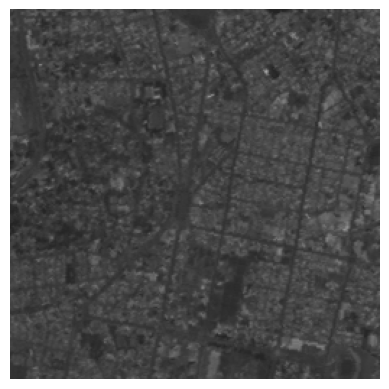

In [461]:
quito_img = cv2.imread('images/QUITO.png', cv2.IMREAD_GRAYSCALE)

plt.imshow(quito_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

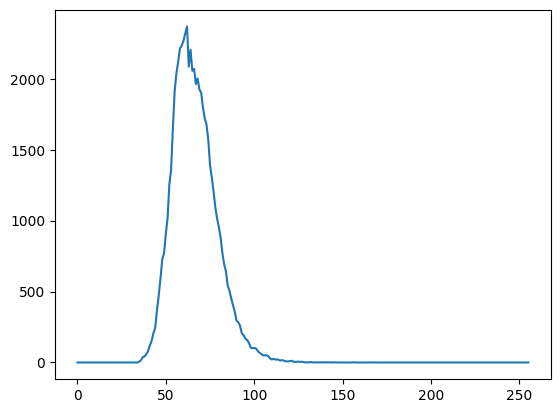

In [462]:
quito_hist = get_histogram(quito_img)
plt.plot(quito_hist)
plt.show()

### 2.4. Efectúe una ecualización del histograma, visualice la imagen resultado y su histograma. En este caso particular, ¿a qué se debe la discontinuidad del histograma ecualizado?

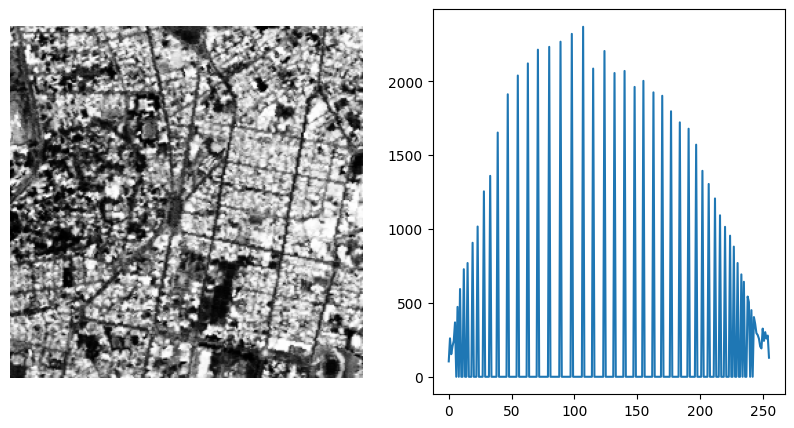

In [463]:
quito_equ = cv2.equalizeHist(quito_img)
quito_equ_hist = get_histogram(quito_equ)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(quito_equ, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1,2,2)
plt.plot(quito_equ_hist)
plt.show()

La discontinuidad se debe a que la ecualización del histograma redistribuye los niveles de intensidad de la imagen original para lograr una distribución más uniforme. Dado a que el histograma es discreto, y los valores de intensidad de la imagen original se encuentran en un rango específico y estrecho, la ecualización redistribuye las intensidades de los píxeles existente, cambia el valor de la intensidad pero no su frecuencia, por lo que no se crean frecuencias de intensidades nuevas, sino que se redistribuyen las frecuencias existentes. Esto puede resultar en una distribución de intensidades que no es completamente uniforme, lo que se refleja en la discontinuidad del histograma ecualizado. El número de barras del histograma no aumento, solo se redistribuye.

### 2.5. Efectúe una segunda vez esta operación. Es decir, aplique una ecualización del histograma a la imagen resultado del punto anterior. ¿Qué pasa? ¿Por qué?

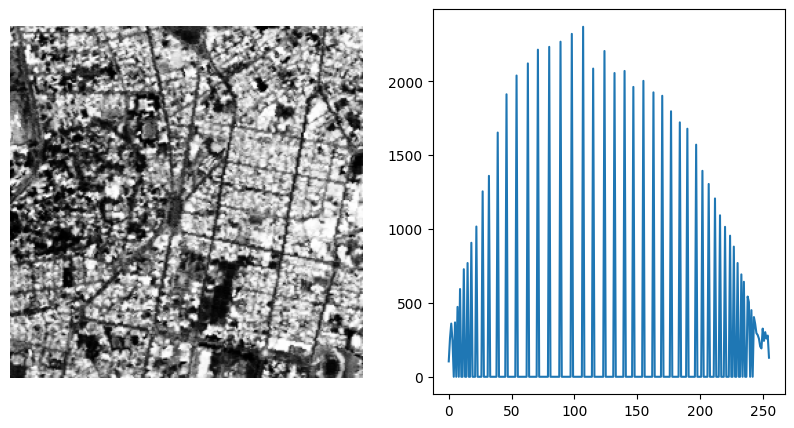

In [464]:
quito_equ2 = cv2.equalizeHist(quito_equ)
quito_equ2_hist = get_histogram(quito_equ2)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(quito_equ2, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1,2,2)
plt.plot(quito_equ2_hist)
plt.show()

No se notan que hayan cambios en la imagen o en el histograma, esto se debe a que la ecualización previo ya redistribuyó los niveles de intensidad de la imagen para lograr una distribución lo más uniforme posible, una vez que los niveles de gris han sido redistribuidos de la forma más uniforme que permiten los datos discretos de la imagen, la función de transferencia se vuelve aproximadamente lineal, haciendo que una segunda o tercera ecualización no tengan un efecto significativo en el histograma, volviendosa casi una operación idempotente.

### 2.6. Repita las operaciones 1 a 4 con la imagen baboon.png. ¿Cómo es el resultado de esta transformación comparado con la ecualización de la imagen precedente (quito.png)? ¿Por qué?

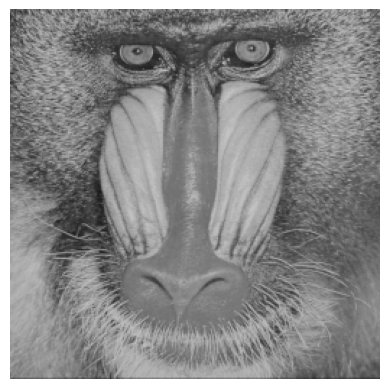

In [465]:
baboon_img = cv2.imread('images/baboon.png', cv2.IMREAD_GRAYSCALE)

plt.imshow(baboon_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

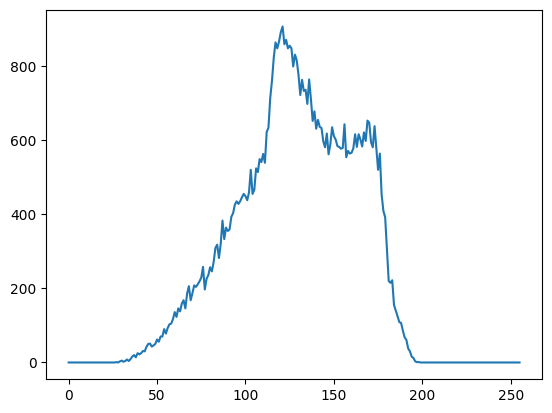

In [466]:
baboon_hist = get_histogram(baboon_img)
plt.plot(baboon_hist)
plt.show()

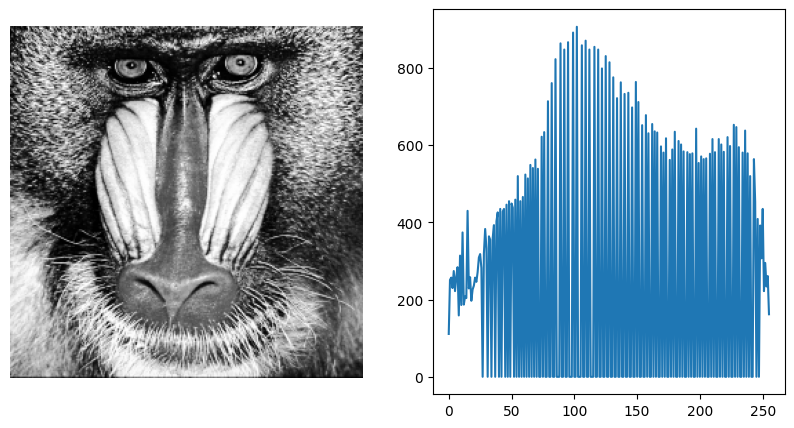

In [467]:
baboon_equ = cv2.equalizeHist(baboon_img)
baboon_equ_hist = get_histogram(baboon_equ)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(baboon_equ, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1,2,2)
plt.plot(baboon_equ_hist)
plt.show()

La composición de la imagen de *baboon.png* es inicialmente diferente a la de *quito.png*, pues al ver su histograma se observa un contraste inicial mayor y una distribución de niveles de intensidad de gris más amplia: de 30 a 200 en comparación de 40 a 120. Como la imagen de *quito.png* tiene un contraste muy bajo y un histograma más agrupado, la ecualización genera un cambio visual más significativo y una redistribución más notoria de los niveles de intensidad.

El histograma de *baboon.png* ecualizado muestra una distribución sin tanta discontinuidad como el de *quito.png*. Al haber más niveles de gris presentes en la imagen original, la ecualización puede distribuir los niveles de intensidad de manera más uniforme sin crear tantas brechas en el histograma resultante, aunque sigue habiendo cierta discontinuidad debido a la naturaleza discreta de los datos.

# 3. Comparación entre diferentes transformaciones del histograma

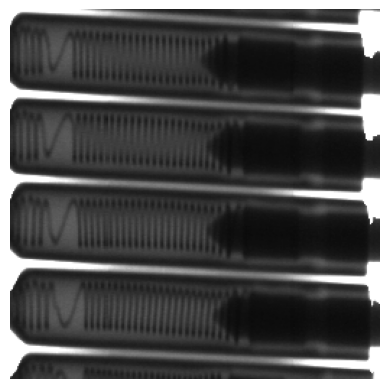

In [468]:
bougies_img = cv2.imread('images/BOUGIES.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(bougies_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

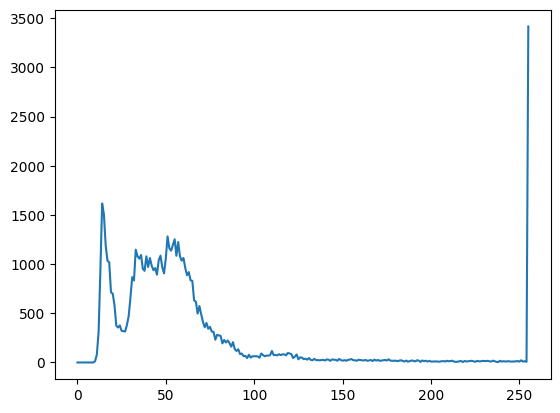

In [469]:
bougies_hist = get_histogram(bougies_img)
plt.plot(bougies_hist)
plt.show()

### 3.4. Efectúe una expansión del contraste, visualice la imagen resultado y su histograma. Compare las imágenes (original y después de la expansión), junto con sus histogramas. ¿A qué se debe este resultado?

Expansión de contraste con A = 10 y B = 255


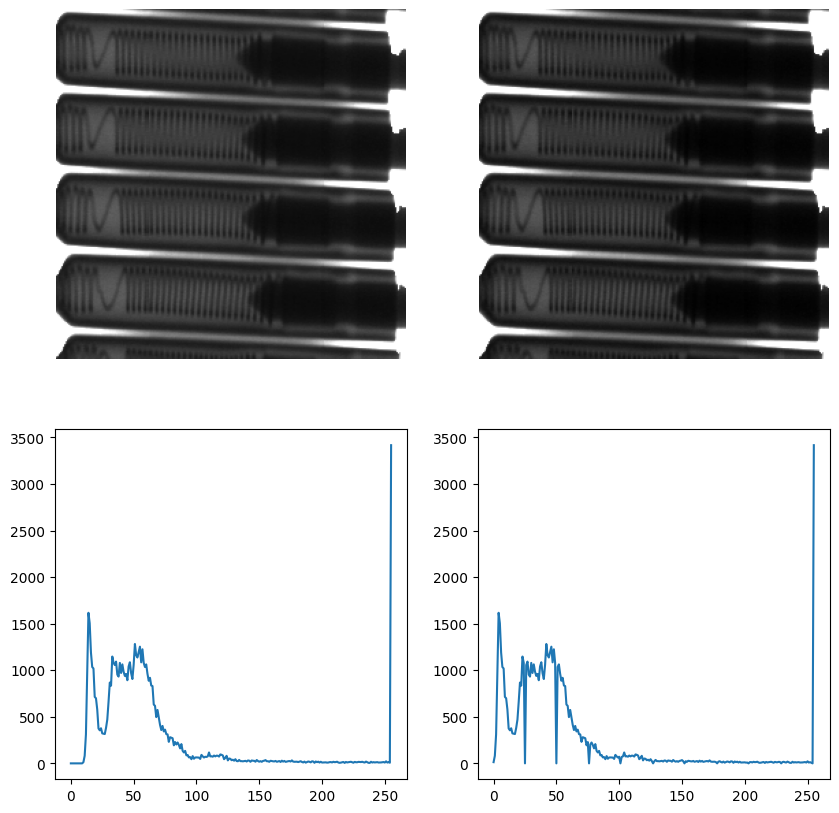

In [470]:
A, B = np.min(bougies_img), np.max(bougies_img)
print("Expansión de contraste con A =", A, "y B =", B)
rescaled_bougies = exposure.rescale_intensity(bougies_img, in_range=(A,B), out_range=(0,255)).astype(np.uint8)
rescaled_bougies_hist = get_histogram(rescaled_bougies)

plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
plt.imshow(bougies_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(rescaled_bougies, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(2,2,3)
plt.plot(bougies_hist)

plt.subplot(2,2,4)
plt.plot(rescaled_bougies_hist)

plt.show()

La imagen cambia muy poco en su aspecto visual. Esto se debe a que la imagen original tiene un rango dinámico de niveles de intensidad de gris (10-255) que abarca casi todo el rango posible (0-255), por lo que la expansión del contraste no tiene un efecto significativo en la apariencia de la imagen. El histograma de la imagen original ya está bastante distribuido a lo largo del rango de intensidades, por lo que la expansión del contraste no produce una redistribución significativa de los niveles de intensidad, resultando en una imagen y un histograma que se parecen mucho a los originales. De todos modos, se observa una ligera diferencia en los tonos de gris más oscuros, que se vuelven un poco más oscuros, visible en las estructuras que parecen resortes y en los cuerpos negros que se encuentran en la parte derecha de la imagen.

### 3.5. Sobre la imagen original efectúe ahora una ecualización del histograma, visualice la imagen resultado y su histograma. Compare las imágenes resultado de la expansión (punto anterior) y de la ecualización (resultado actual), junto con sus histogramas. Comente sus observaciones.

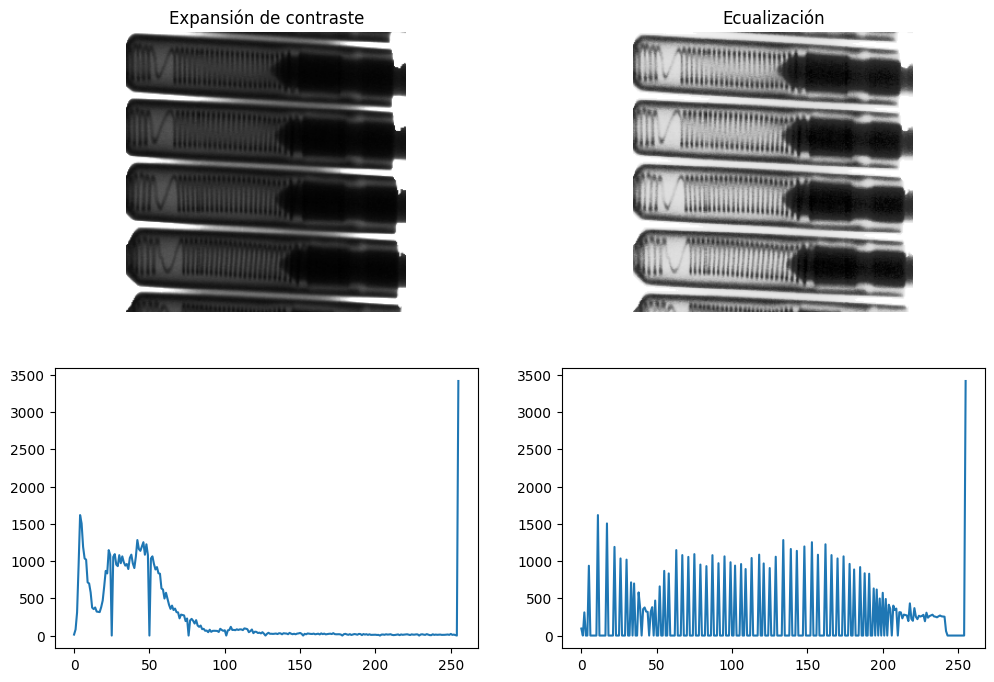

In [471]:
bougies_equ = cv2.equalizeHist(bougies_img)
bougies_equ_hist = get_histogram(bougies_equ)

plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.imshow(rescaled_bougies, cmap="gray", vmin=0, vmax=255)
plt.title("Expansión de contraste")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(bougies_equ, cmap="gray", vmin=0, vmax=255)
plt.title("Ecualización")
plt.axis("off")

plt.subplot(2,2,3)
plt.plot(rescaled_bougies_hist)

plt.subplot(2,2,4)
plt.plot(bougies_equ_hist)

plt.show()

La expansión conserva la forma del histograma original pero la estira a lo largo del rango completo de niveles de intensidad de gris. Por su parte, la ecualización es una transformación no lineal que busca cambiar la forma del histograma basada en distribución uniforme, redistribuyendo la intensidad de los pixeles para que tenga una probabilidad más similar de aparecer. El histograma expandido sigue sigue concentrado en los valores bajos y medios, pero ahora empieza desde 0, mientras que el histograma ecualizado se encuentra más disperso a lo largo de todo el rango de intensidades de gris.

El contraste en las zonas de gris oscuro aumenta al realizar la ecualización, donde ahora solo se observan intensidades bajas en los objetos que parecen resortes. Esto permite identificar con mayor claridad su forma sin que los alrededores se vean sombreados.

### 3.6. Sobre la imagen original aplique ahora una transformación logarítmica y multiplique la imagen resultado por un valor constante de 46. ¿Por qué es necesario multiplicar la imagen de salida por un factor? Visualice la imagen resultado y su histograma. ¿Cómo es el histograma resultado?

Rango de intensidades de la imagen original:
[10, 255]
	Número de niveles de gris diferentes: 246

Rango de intensidades de la imagen tras aplicar r = log(1+s):
[2.3978952727983707, 5.545177444479562]
	Número de niveles de gris diferentes: 246
	Número de niveles de gris diferentes y enteros: 4

Rango de intensidades de la imagen tras aplicar r = c * log(1+s):
[110.30318254872505, 255.07816244605988]
	Número de niveles de gris diferentes: 246
	Número de niveles de gris diferentes y enteros: 115



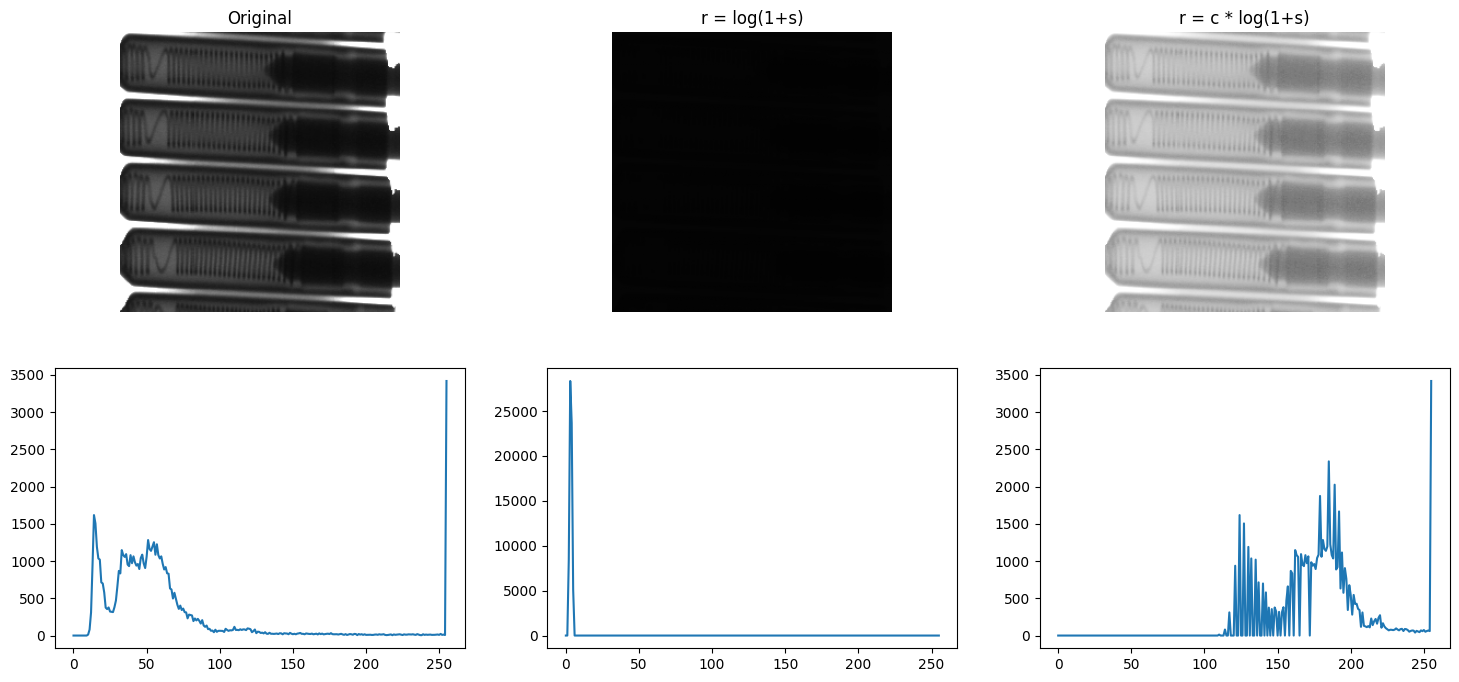

In [472]:
bougies_log = np.log1p(bougies_img.astype(np.float64))
c = 46
bougies_log_c = c * bougies_log # multiplicar por la constante

# convertir a uint8 para utilizar numeros enteros que maneja opencv y matplotlib
bougies_log_8 = bougies_log.astype(np.uint8)
bougies_log_c_8 = bougies_log_c.astype(np.uint8)

print(f"Rango de intensidades de la imagen original:")
print(f"[{np.min(bougies_img)}, {np.max(bougies_img)}]")
print(f"\tNúmero de niveles de gris diferentes: {len(np.unique(bougies_img))}\n")

print(f"Rango de intensidades de la imagen tras aplicar r = log(1+s):")
print(f"[{np.min(bougies_log)}, {np.max(bougies_log)}]")
print(f"\tNúmero de niveles de gris diferentes: {len(np.unique(bougies_log))}")
print(f"\tNúmero de niveles de gris diferentes y enteros: {len(np.unique(bougies_log_8))}\n")

print(f"Rango de intensidades de la imagen tras aplicar r = c * log(1+s):")
print(f"[{np.min(bougies_log_c)}, {np.max(bougies_log_c)}]")
print(f"\tNúmero de niveles de gris diferentes: {len(np.unique(bougies_log_c))}")
print(f"\tNúmero de niveles de gris diferentes y enteros: {len(np.unique(bougies_log_c_8))}\n")

bougies_log_hist = get_histogram(bougies_log_8)
bougies_log_c_hist = get_histogram(bougies_log_c_8)

plt.figure(figsize=(18, 8))

plt.subplot(2,3,1)
plt.imshow(bougies_img, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.title("Original")

plt.subplot(2,3,2)
plt.imshow(bougies_log_8, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.title("r = log(1+s)")

plt.subplot(2,3,3)
plt.imshow(bougies_log_c_8, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.title("r = c * log(1+s)")

plt.subplot(2,3,4)
plt.plot(bougies_hist)

plt.subplot(2,3,5)
plt.plot(bougies_log_hist)

plt.subplot(2,3,6)
plt.plot(bougies_log_c_hist)

plt.show()

Multiplicar la imagen de salida por un factor es necesario porque la función de logaritmo comprime el rango de los valores de intensidades (nota: $log$ have referencia al logaritmo natural):
* Si los píxeles de la imagen $s$ están en el rango $[10, 255]$, el valor mínimo de la transformación es $log(1+s) = log(1+10) = log(11) = 2.40$, y el valor máximo de la transformación es $log(1+255) = log(256) = 5.54$. Los valores dentro de este rango representan intensidades de gris muy oscuras, y una vez son convertidos a enteros solo se tiene un rango de $[2, 6]$, 5 niveles de gris para la imagen. Una imagen con valores de gris entre 2 y 6 se ve negra y tendrá pocas diferencias entre estructuras. 
* La constante se calcula para ampliar este valor máximo y por consecuencia, el rango al convertir los valores de la matriz de la imagen a enteros. Se desea obtener un número que multiplicado por 5.45 sea igual a 255 y se obtienes de la siguiente manera:

$$ c = \frac{255}{log(1+255)} \approx \frac{255}{5.54} \approx 45.98 \approx 46 $$
* Al multiplicar el resultado de la operación de $log(1+s)$ por $c$ se logra que las intensidades se amplien a todo el rango dinámico de la transformación, resultando en el rango $[110.3, 255.1]$.

El histograma resultado muestra un desplazamiento hacia la derecha de los valores de intensidad. Esto quiere decir que ahora la imagen tiene una mayor área de zonas claras (110-220), en lugar de zonas grises oscuras (10, 100).

### 3.7. Sobre la imagen original efectúe ahora una especificación de dos histogramas diferentes de entrada. Visualice la imagen resultado, los histogramas esperados y los histogramas obtenidos. Compare los resultados con los de los puntos anteriores. Comente sus observaciones.

In [473]:
def get_reference_hist(N, M, t="gauss", L=256):
    x = np.arange(L)
    if t == "gauss":
        mu, sigma = 128, 40
        obj_hist = np.exp(-((x - mu)**2) / (2 * sigma**2))
    elif t == "bimodal":
        # Bimodal, dos picos
        obj_hist = np.exp(-((x - 60)**2) / (2 * 20**2)) + np.exp(-((x - 190)**2) / (2 * 20**2))
    
    # normalizar y obtener CDF
    obj_hist /= obj_hist.sum()
    cdf = np.cumsum(obj_hist)
    
    pixel_values = np.interp(np.random.rand(N * M), cdf, range(0, L))
    return pixel_values.reshape(N, M).astype(np.uint8), obj_hist

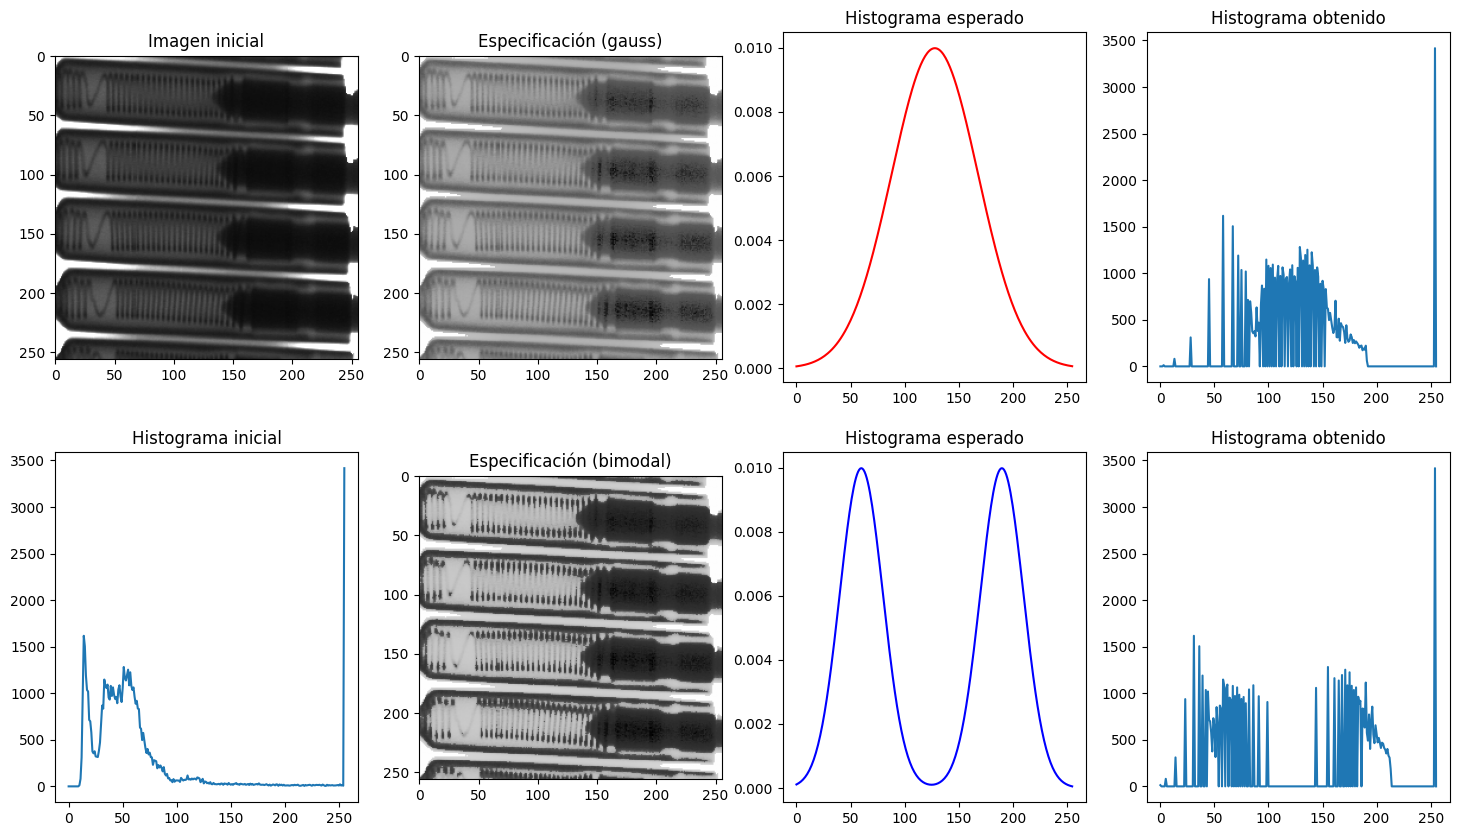

In [474]:
N, M = bougies_img.shape
ref_1, target_hist_1 = get_reference_hist(N, M, "gauss")
ref_2, target_hist_2 = get_reference_hist(N, M, "bimodal")

matched_1 = exposure.match_histograms(bougies_img, ref_1).astype(np.uint8)
matched_2 = exposure.match_histograms(bougies_img, ref_2).astype(np.uint8)

matched_1_hist = get_histogram(matched_1)
matched_2_hist = get_histogram(matched_2)

fig, axs = plt.subplots(2, 4, figsize=(18, 10))

axs[0, 0].imshow(bougies_img, cmap='gray', vmin=0, vmax=255)
axs[0, 0].set_title("Imagen inicial")
axs[1, 0].plot(bougies_hist)
axs[1, 0].set_title("Histograma inicial")

axs[0, 1].imshow(matched_1, cmap='gray', vmin=0, vmax=255)
axs[0, 1].set_title('Especificación (gauss)')
axs[0, 2].plot(target_hist_1, color='red')
axs[0, 2].set_title('Histograma esperado')
axs[0, 3].plot(matched_1_hist)
axs[0, 3].set_title('Histograma obtenido')

axs[1, 1].imshow(matched_2, cmap='gray', vmin=0, vmax=255)
axs[1, 1].set_title('Especificación (bimodal)')
axs[1, 2].plot(target_hist_2, color='blue')
axs[1, 2].set_title('Histograma esperado')
axs[1, 3].plot(matched_2_hist)
axs[1, 3].set_title('Histograma obtenido')

plt.show()

A diferencia de la ecualización, que siempre intenta aplanar el histograma, la especificación permite decidir qué zonas se quieren resaltar. Con el objetivo Gaussiano, la imagen concentra sus grises en los tonos medios, suavizando zonas donde hay alto contraste local. Con el objetivo Bimodal, se quiere que la imagen tenga muchos oscuros y muchos claros, separando los objetos, y en aplicaciones generales, separando el objeto del fondo.

A diferencia de los puntos anteriores, la especificación permite un mayor control obre el histograma, donde la especificación basada en una camapana de Gauss genera una suavizado de la imagen y disminuye el contraste local.

La especificación bimodal resalta los claros y oscuros de la imagen pero genera un aspecto visual poco natural donde se pierden los tonos medios.

### 3.8. Haga una comparación entre los tipos de transformaciones ¿Qué impactos tiene cada una? ¿Cómo  pueden ser usadas en el ámbito de mejoramiento de la calidad de la imagen?

Ya se realizaron opearaciones de expansión de contraste, ecualización y especifciación sobre el histograma original. A continuación se presenta una tabla con el resumen de las observaciones generales:

| **Transformación** | **Resultado visual** | **Operación sobre el histograma**|
|---|---|---|
| Expansión | Mejora más natural y menos agresiva del contraste | (Bajo) Lineal, se estira el histograma |
| Ecualización | Mejora general del contraste, mayor rango dinámico y equilibración del área de zonas claras y oscuras | (Medio) No lineal, se aplana el histograma |
| Logaritmica | Aclara la imagen, hay menos zonas oscuras | (Medio) No lineal, el histograma se corre hacia la derecha |
| Especificación | Resultado personalizado según la necesidad | (Alto) No lineal, el histograma se moldea según el histograma objetivo |

La expansión de contraste usualmente si utiliza para el preprocesamiento de imagenes que serán utilizadas por modelos de machine learning, donde se busca que todas las imágnes de entrada tengan el mismo rango. También se puede emplear para mejorar en contraste en imagenes que inicialmente tengan un contraste bajo.

La ecualización se puede usar para incrementar el contraste visual de la image. Cuando la imagen puede tener un alto contraste pero su valores máximos y mínimos tengan poca frecuencia, por lo que el contraste visual inicial se ve bajo, se puede aplicar la ecualización para obtener mayores detalles visualmente.

La transformación logaritmica se puede emplear para aclarar la imagen y eliminar zonas oscuras y de sombra. Por ejemplo una imagen donde la estructura principal tiene una parte oscura y se quiere que esa estructura se vea visualmente uniforme.

La especificación se suele utilizar para igualar histogramas de imagenes que son parte de datasets que incluyen imagenes tomadas con diferentes máquinas y parámetros de las cámaras. De este modo se aplica una especificación o ecualización para eliminar los estilos de cada maquina o combinación de parámetros y estandarizar los datos de entrada para modelos de machine learninng. La especificación también se puede utilizar para resaltar ciertas características de la imagen, por ejemplo las zonas claras contra las zonas oscuras, o aumentar el constraste de rangos específicos de intensidades para obtener mayor detalle en las zonas de intensidad deseadas.

# 4. Umbralización simple

# 5. Umbralización doble

# 6. Ejercicio de síntesis taller 2